# 📈 FinSightAI — Stock Price Forecasting (Multi-Stock Prophet)
---

**What this notebook does:**
1. Load ALL 11 stock CSV files (Apple, Amazon, Tesla, Nvidia, etc.)
2. Explore & visualize each stock individually
3. Normalize prices (base-100) so all stocks are comparable
4. Combine into a "market composite index"
5. Train a Prophet model on the combined data
6. Run walk-forward backtesting (proper evaluation)
7. Compare Prophet vs a naive baseline
8. Generate future forecasts
9. Save the trained model

> This is the training pipeline for the production forecast endpoint
> in our FastAPI backend (`/ml/forecast/`).

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
import joblib

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# make plots look nice
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

# suppress prophet's noisy logs
warnings.filterwarnings("ignore")

print("All imports done!")

Importing plotly failed. Interactive plots will not work.


All imports done!


## Step 2: Load All Stock CSV Files

We have 11 different financial instruments in `datasets/forecasting/`:
- **Stocks:** Apple, Amazon, Tesla, Nvidia, Meta, Microsoft, Adobe, Qualcomm
- **Crypto:** Bitcoin
- **Commodities:** Gold
- **Bonds:** Treasury Bill

In [3]:
# find all csv files in the forecasting folder
csv_dir = "../datasets/forecasting/"
csv_files = sorted(glob.glob(os.path.join(csv_dir, "*.csv")))

print(f"Found {len(csv_files)} CSV files:\n")

for f in csv_files:
    name = os.path.basename(f)
    df_temp = pd.read_csv(f)
    print(f"  {name:30s} -> {len(df_temp)} rows")

Found 11 CSV files:

  adobe_stock.csv                -> 526 rows
  amazon_stock.csv               -> 526 rows
  apple_stock.csv                -> 526 rows
  bitcoin.csv                    -> 759 rows
  gold.csv                       -> 522 rows
  meta_stock.csv                 -> 526 rows
  microsoft_stock.csv            -> 526 rows
  nvidia_stock.csv               -> 526 rows
  qualcomm_stock.csv             -> 526 rows
  tesla_stock.csv                -> 526 rows
  treasury_bill.csv              -> 446 rows


In [4]:
# load all csvs into a dictionary
stock_data = {}

for csv_path in csv_files:
    # get a clean name like "apple", "amazon", etc.
    name = os.path.basename(csv_path).replace("_stock.csv", "").replace(".csv", "")

    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    stock_data[name] = df

print(f"Loaded {len(stock_data)} stocks: {list(stock_data.keys())}")

Loaded 11 stocks: ['adobe', 'amazon', 'apple', 'bitcoin', 'gold', 'meta', 'microsoft', 'nvidia', 'qualcomm', 'tesla', 'treasury_bill']


## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Basic Info for Each Stock

In [5]:
# show basic info for each stock
for name, df in stock_data.items():
    date_range = f"{df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}"
    price_range = f"${df['Close'].min():.2f} - ${df['Close'].max():.2f}"
    print(f"{name:15s} | {len(df):4d} rows | {date_range} | Close: {price_range}")

adobe           |  526 rows | 2019-05-31 to 2021-06-30 | Close: $259.03 - $590.75
amazon          |  526 rows | 2019-05-31 to 2021-06-30 | Close: $1676.61 - $3531.45
apple           |  526 rows | 2019-05-31 to 2021-06-30 | Close: $42.46 - $142.49
bitcoin         |  759 rows | 2019-05-31 to 2021-07-01 | Close: $4970.79 - $63503.46
gold            |  522 rows | 2019-05-31 to 2021-07-01 | Close: $1305.80 - $2051.50
meta            |  526 rows | 2019-05-31 to 2021-06-30 | Close: $146.01 - $355.64
microsoft       |  526 rows | 2019-05-31 to 2021-06-30 | Close: $117.25 - $271.40
nvidia          |  526 rows | 2019-05-31 to 2021-06-30 | Close: $33.31 - $200.27
qualcomm        |  526 rows | 2019-05-31 to 2021-06-30 | Close: $59.28 - $163.17
tesla           |  526 rows | 2019-05-31 to 2021-06-30 | Close: $35.79 - $883.09
treasury_bill   |  446 rows | 2019-05-31 to 2021-07-01 | Close: $-0.10 - $2.30


### 3.2 Check for Missing Values

In [6]:
# check for missing values
print("Missing values per stock:\n")

for name, df in stock_data.items():
    missing = df[["Date", "Close"]].isnull().sum().sum()
    print(f"  {name:15s}: {missing} missing values")

all_clean = all(
    df[["Date", "Close"]].isnull().sum().sum() == 0
    for df in stock_data.values()
)
print("\nAll clean!" if all_clean else "\nSome stocks have missing data!")

Missing values per stock:

  adobe          : 0 missing values
  amazon         : 0 missing values
  apple          : 0 missing values
  bitcoin        : 0 missing values
  gold           : 0 missing values
  meta           : 0 missing values
  microsoft      : 0 missing values
  nvidia         : 0 missing values
  qualcomm       : 0 missing values
  tesla          : 0 missing values
  treasury_bill  : 0 missing values

All clean!


### 3.3 Plot Each Stock's Closing Price

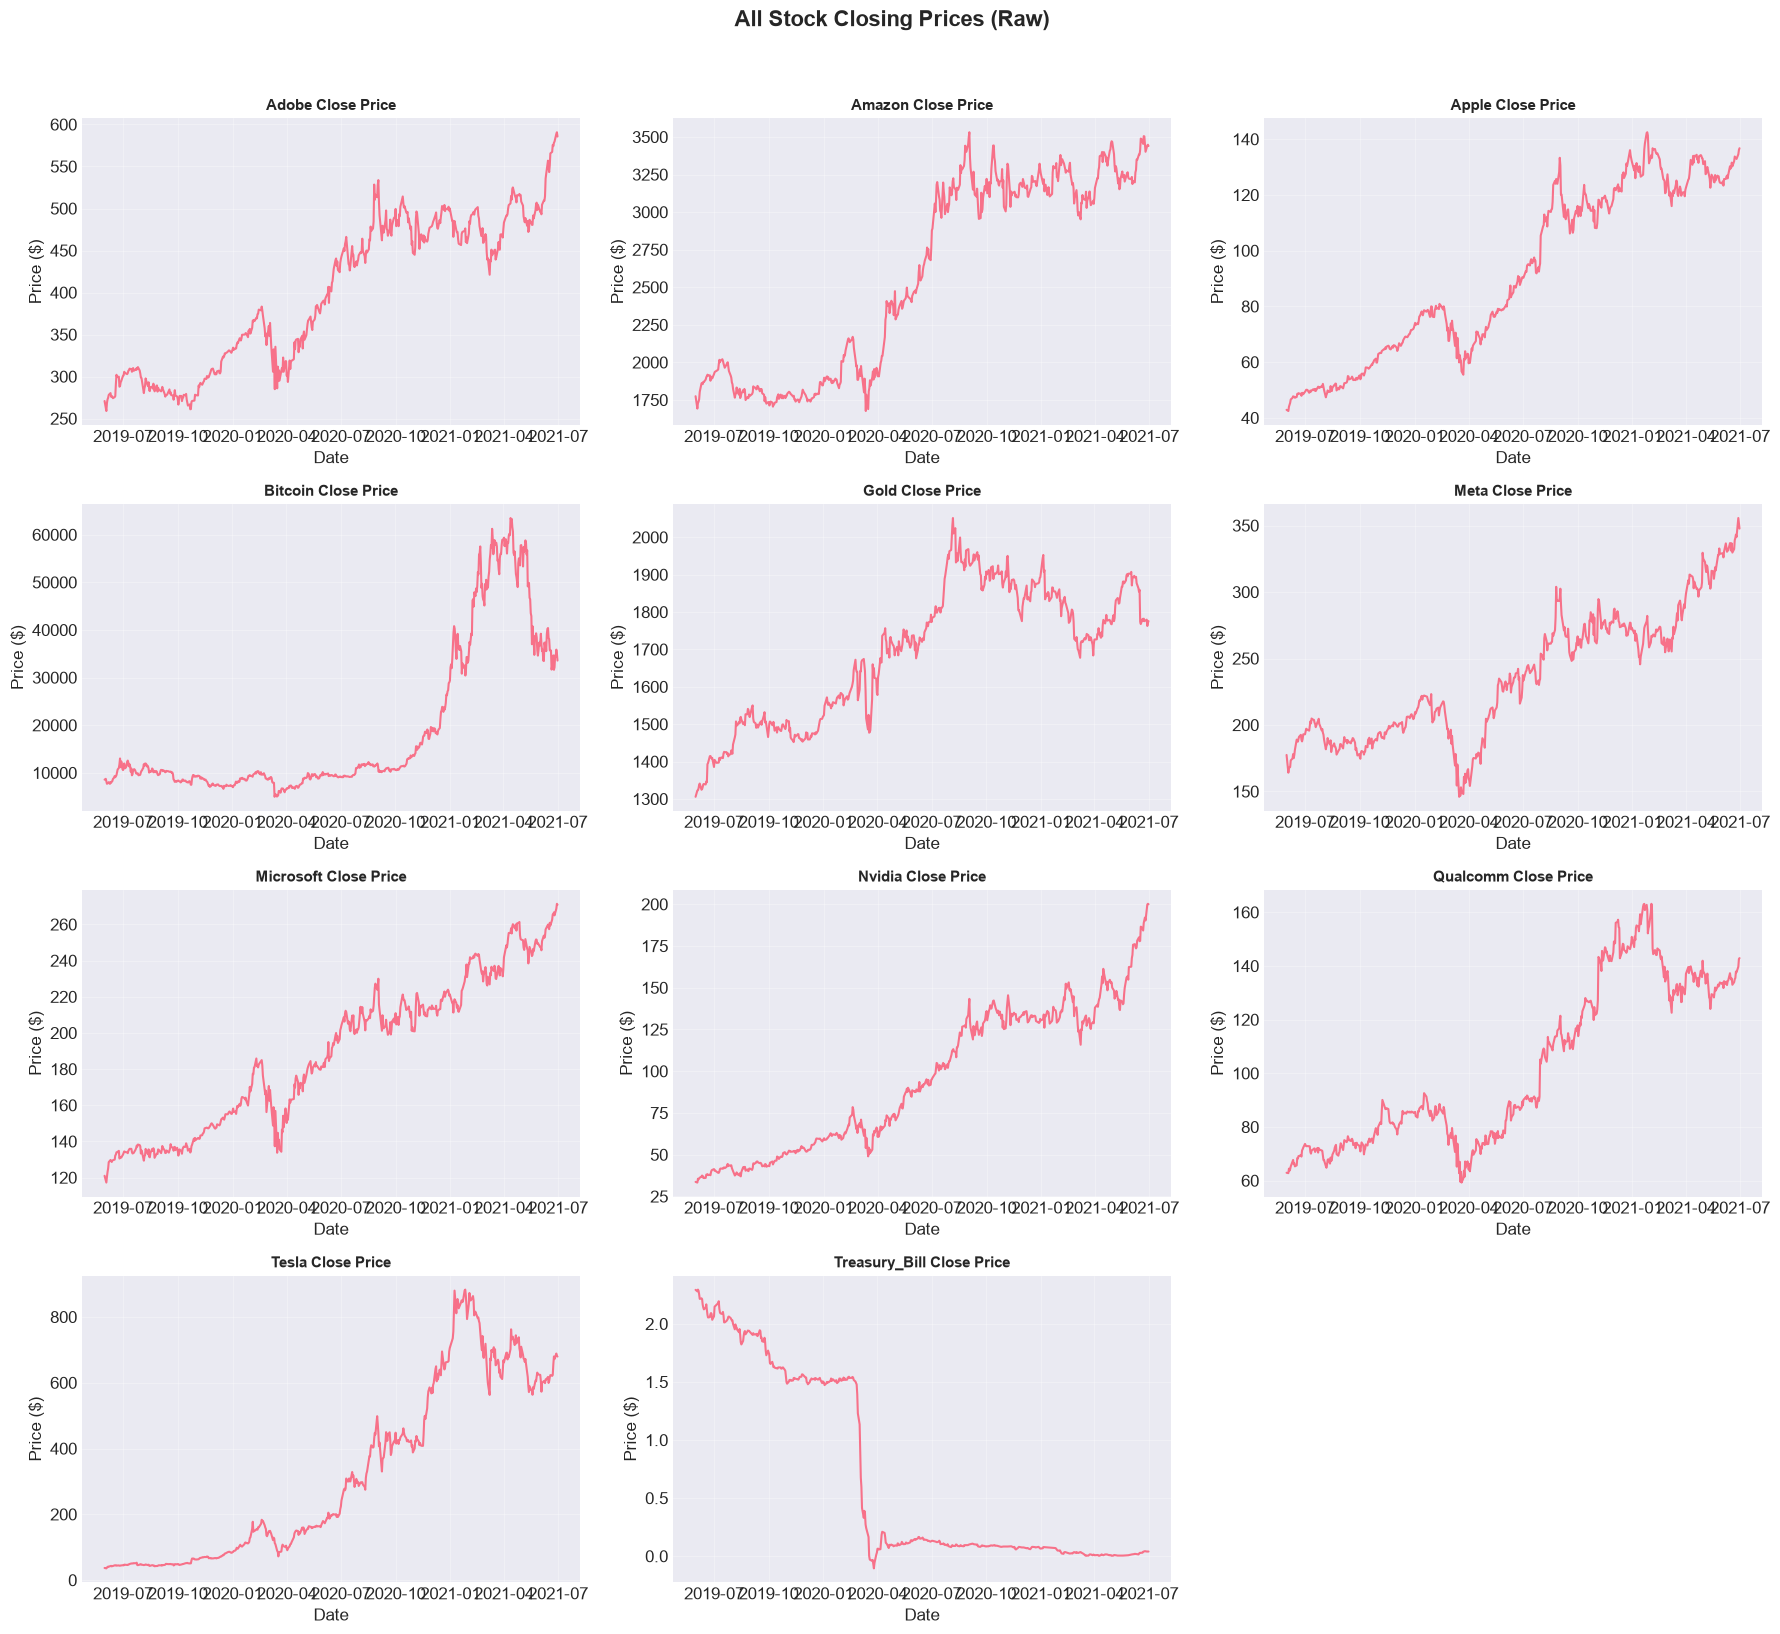

In [7]:
# plot all stocks in a grid
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, (name, df) in enumerate(stock_data.items()):
    ax = axes[i]
    ax.plot(df["Date"], df["Close"], linewidth=1.5)
    ax.set_title(f"{name.title()} Close Price", fontsize=11, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price ($)")
    ax.grid(True, alpha=0.3)

# hide extra subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("All Stock Closing Prices (Raw)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Summary Statistics

In [8]:
# build a summary table
summary_rows = []

for name, df in stock_data.items():
    summary_rows.append({
        "Stock": name.title(),
        "Rows": len(df),
        "Start Price": round(df["Close"].iloc[0], 2),
        "End Price": round(df["Close"].iloc[-1], 2),
        "Min": round(df["Close"].min(), 2),
        "Max": round(df["Close"].max(), 2),
        "Mean": round(df["Close"].mean(), 2),
        "Std": round(df["Close"].std(), 2),
        "Return %": round((df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100, 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Return %", ascending=False)
summary_df

,Stock,Rows,Start Price,End Price,Min,Max,Mean,Std,Return %
9,Tesla,526,37.03,679.70,35.79,883.09,320.16,265.52,1735.4
7,Nvidia,526,33.73,200.02,33.31,200.27,95.18,43.17,493.0
3,Bitcoin,759,8574.50,33572.12,4970.79,63503.46,18911.30,16222.81,291.5
2,Apple,526,42.90,136.76,42.46,142.49,91.66,30.67,218.8
8,Qualcomm,526,62.94,142.93,59.28,163.17,102.13,29.92,127.1
6,Microsoft,526,121.00,270.90,117.25,271.40,188.30,41.75,123.9
0,Adobe,526,270.90,585.64,259.03,590.75,398.59,89.02,116.2
5,Meta,526,177.47,347.71,146.01,355.64,236.39,48.59,95.9
1,Amazon,526,1775.07,3440.16,1676.61,3531.45,2570.08,651.12,93.8
4,Gold,522,1305.80,1775.90,1305.80,2051.50,1692.69,179.86,36.0


## Step 4: Normalize Prices (Base-100)

**Problem:** Each stock has a totally different price scale.
- Amazon = ~$3,400 | Apple = ~$130 | Treasury Bill = ~$0.04

**Solution:** Normalize so first price = 100.

`normalized = (price / first_price) * 100`

In [9]:
# normalize each stock to base-100
normalized_stocks = {}

for name, df in stock_data.items():
    norm_df = df[["Date", "Close"]].copy()

    first_price = norm_df["Close"].iloc[0]
    norm_df["Close_Normalized"] = (norm_df["Close"] / first_price) * 100.0

    normalized_stocks[name] = norm_df

# show before vs after
print("Before vs After normalization:\n")
for name in ["apple", "amazon", "tesla", "gold"]:
    raw_first = stock_data[name]["Close"].iloc[0]
    raw_last = stock_data[name]["Close"].iloc[-1]
    norm_first = normalized_stocks[name]["Close_Normalized"].iloc[0]
    norm_last = normalized_stocks[name]["Close_Normalized"].iloc[-1]
    print(f"  {name:10s}: ${raw_first:>10.2f} -> {norm_first:>7.2f}  |  ${raw_last:>10.2f} -> {norm_last:>7.2f}")

Before vs After normalization:

  apple     : $     42.90 ->  100.00  |  $    136.76 ->  318.79
  amazon    : $   1775.07 ->  100.00  |  $   3440.16 ->  193.80
  tesla     : $     37.03 ->  100.00  |  $    679.70 -> 1835.44
  gold      : $   1305.80 ->  100.00  |  $   1775.90 ->  136.00


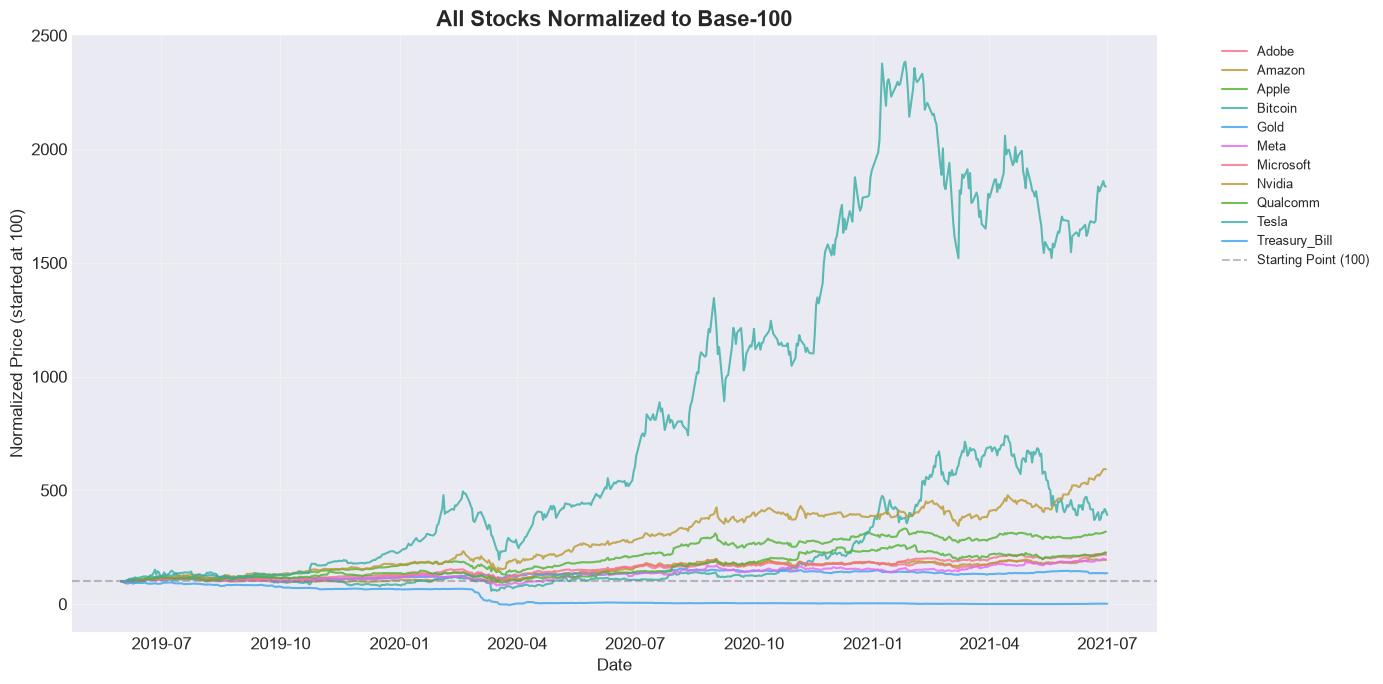

In [10]:
# plot all stocks AFTER normalization
plt.figure(figsize=(14, 7))

for name, df in normalized_stocks.items():
    plt.plot(df["Date"], df["Close_Normalized"], linewidth=1.5, label=name.title(), alpha=0.8)

plt.axhline(y=100, color="gray", linestyle="--", alpha=0.5, label="Starting Point (100)")
plt.title("All Stocks Normalized to Base-100", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Normalized Price (started at 100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Combine into Market Composite Index

Average the normalized prices across ALL stocks for each date.
This gives us one clean time series that captures common patterns.

In [11]:
# stack all normalized frames and average by date
all_frames = []

for name, df in normalized_stocks.items():
    temp = df[["Date", "Close_Normalized"]].copy()
    temp = temp.rename(columns={"Close_Normalized": "Close"})
    temp["ticker"] = name
    all_frames.append(temp)

big_df = pd.concat(all_frames, ignore_index=True)

# group by date -> average
composite = big_df.groupby("Date")["Close"].mean().reset_index()
composite = composite.sort_values("Date").reset_index(drop=True)

print(f"Combined dataset: {len(composite)} rows")
print(f"Date range: {composite['Date'].iloc[0].date()} to {composite['Date'].iloc[-1].date()}")
print(f"Price range: {composite['Close'].min():.2f} to {composite['Close'].max():.2f}")
print(f"Stocks included: {len(normalized_stocks)}")

Combined dataset: 763 rows
Date range: 2019-05-31 to 2021-07-01
Price range: 60.65 to 714.25
Stocks included: 11


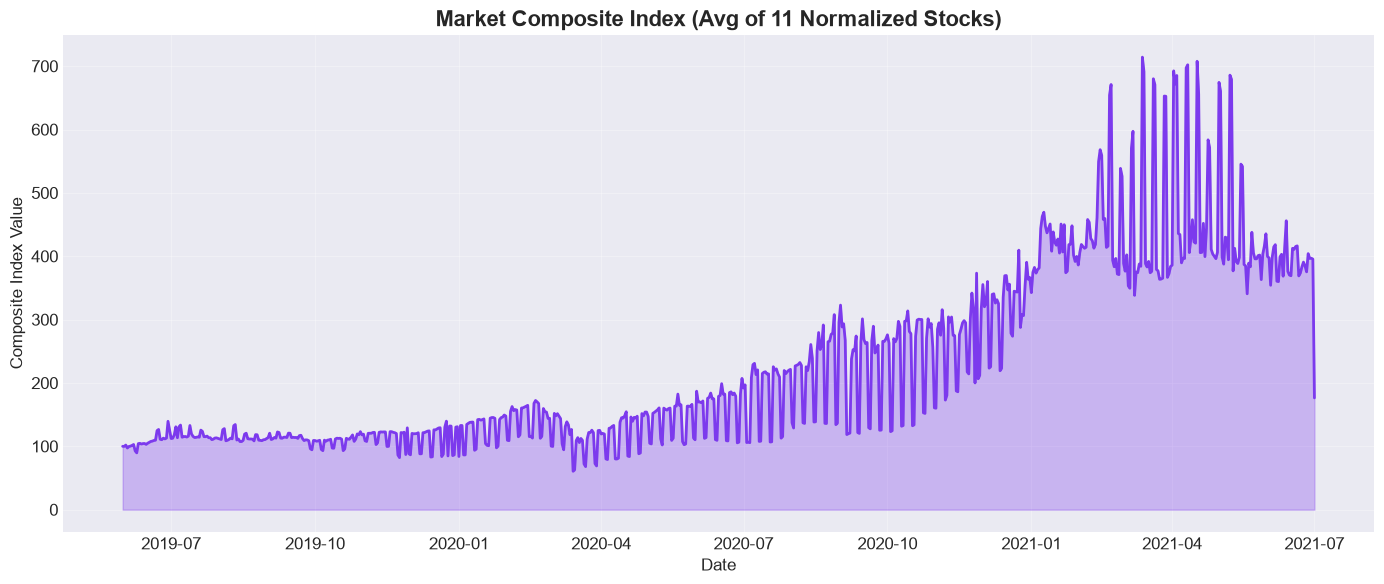

In [12]:
# plot the composite
plt.figure(figsize=(14, 6))

plt.fill_between(composite["Date"], composite["Close"], alpha=0.3, color="#7C3AED")
plt.plot(composite["Date"], composite["Close"], linewidth=2, color="#7C3AED")

plt.title("Market Composite Index (Avg of 11 Normalized Stocks)", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Composite Index Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Prepare Data for Prophet

Prophet needs: `ds` (date) and `y` (value).

In [13]:
# rename for prophet
prophet_df = composite[["Date", "Close"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

print(f"Prophet DataFrame: {prophet_df.shape}")
prophet_df.head()

Prophet DataFrame: (763, 2)


,ds,y
0,2019-05-31,100.000000
1,2019-06-01,99.877715
2,2019-06-02,101.964616
3,2019-06-03,97.363443
4,2019-06-04,99.735497


## Step 7: Simple Train/Test Split (80/20)

Start with a basic split to see if the model works at all.

In [14]:
# 80/20 split
split_idx = int(len(prophet_df) * 0.8)

train_df = prophet_df.iloc[:split_idx].copy()
test_df = prophet_df.iloc[split_idx:].copy()

print(f"Training: {len(train_df)} rows ({train_df['ds'].iloc[0].date()} to {train_df['ds'].iloc[-1].date()})")
print(f"Testing:  {len(test_df)} rows ({test_df['ds'].iloc[0].date()} to {test_df['ds'].iloc[-1].date()})")

Training: 610 rows (2019-05-31 to 2021-01-29)
Testing:  153 rows (2021-01-30 to 2021-07-01)


## Step 8: Train the Prophet Model

**Settings:**
- `yearly_seasonality=False` — only ~2 years of data, would overfit
- `weekly_seasonality=True` — markets have Mon-Fri patterns
- `daily_seasonality=False` — daily data, not hourly
- `changepoint_prior_scale=0.1` — more flexible trend than default

In [15]:
# train prophet
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.1,
)

model.fit(train_df)

print("Prophet model trained!")
print(f"  Training rows: {len(train_df)}")
print(f"  Changepoints: {len(model.changepoints)}")

11:48:57 - cmdstanpy - INFO - Chain [1] start processing
11:48:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained!
  Training rows: 610
  Changepoints: 25


## Step 9: Predict on Test Set

In [16]:
# make future dates covering the test period
future = model.make_future_dataframe(periods=len(test_df), freq="B")
forecast = model.predict(future)

# grab test period predictions
preds = forecast.tail(len(test_df))["yhat"].values
actuals = test_df["y"].values

# handle length mismatch
min_len = min(len(preds), len(actuals))
preds = preds[:min_len]
actuals = actuals[:min_len]

print(f"Predictions: {len(preds)} points")
print(f"Actuals:     {len(actuals)} points")

Predictions: 153 points
Actuals:     153 points


## Step 10: Evaluate (Simple Split)

In [17]:
# metrics
mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

# naive baseline
naive_val = train_df["y"].iloc[-1]
naive_mae = mean_absolute_error(actuals, np.full(len(actuals), naive_val))
mase = mae / naive_mae if naive_mae > 0 else None

print("=" * 50)
print("   80/20 SPLIT RESULTS")
print("=" * 50)
print(f"   MAE:  {mae:.4f}")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAPE: {mape:.2f}%")
print(f"   MASE: {mase:.4f}")
if mase and mase < 1:
    print("   -> Model BEATS naive!")
else:
    print("   -> Comparable to naive")
print(f"\n   Naive MAE: {naive_mae:.4f}")
print("=" * 50)

   80/20 SPLIT RESULTS
   MAE:  175.2581
   RMSE: 203.0897
   MAPE: 43.76%
   MASE: 2.6715
   -> Comparable to naive

   Naive MAE: 65.6021


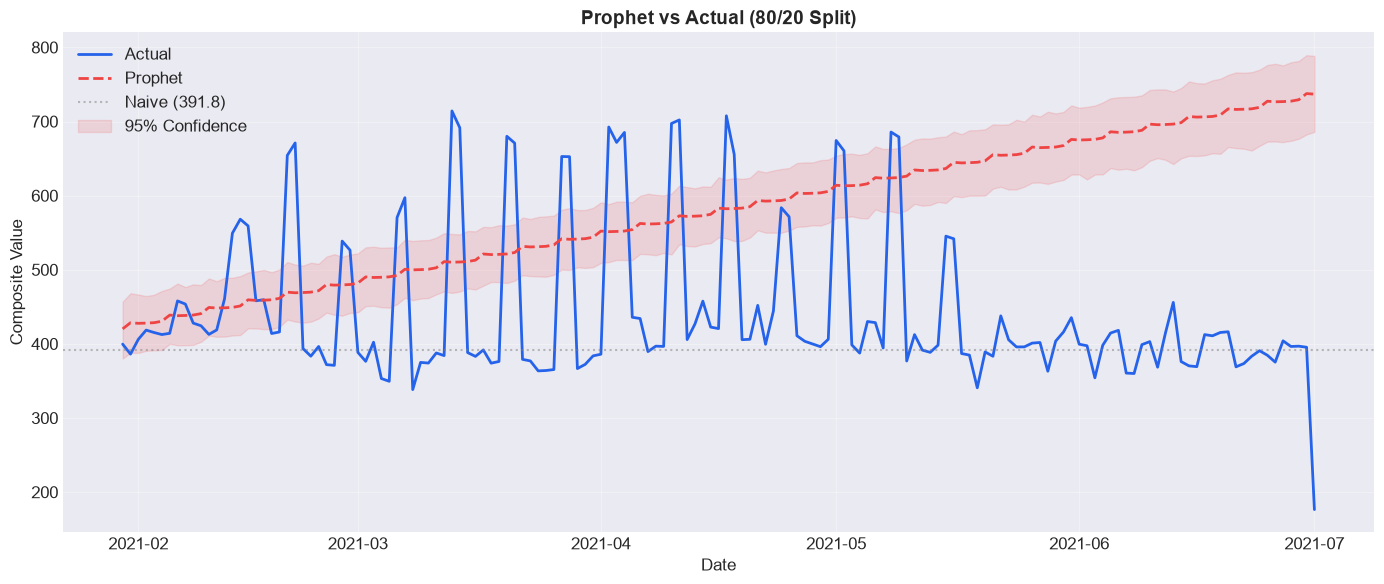

In [18]:
# plot actual vs predicted
plt.figure(figsize=(14, 6))

test_dates = test_df["ds"].values[:min_len]
plt.plot(test_dates, actuals, label="Actual", color="#2563EB", linewidth=2)
plt.plot(test_dates, preds, label="Prophet", color="#ef4444", linewidth=2, linestyle="--")
plt.axhline(y=naive_val, color="gray", linestyle=":", alpha=0.5, label=f"Naive ({naive_val:.1f})")

fc_tail = forecast.tail(min_len)
plt.fill_between(test_dates, fc_tail["yhat_lower"].values, fc_tail["yhat_upper"].values,
                 alpha=0.15, color="#ef4444", label="95% Confidence")

plt.title("Prophet vs Actual (80/20 Split)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Composite Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11: Prophet Components

Prophet decomposes the series into **trend** + **seasonality**.

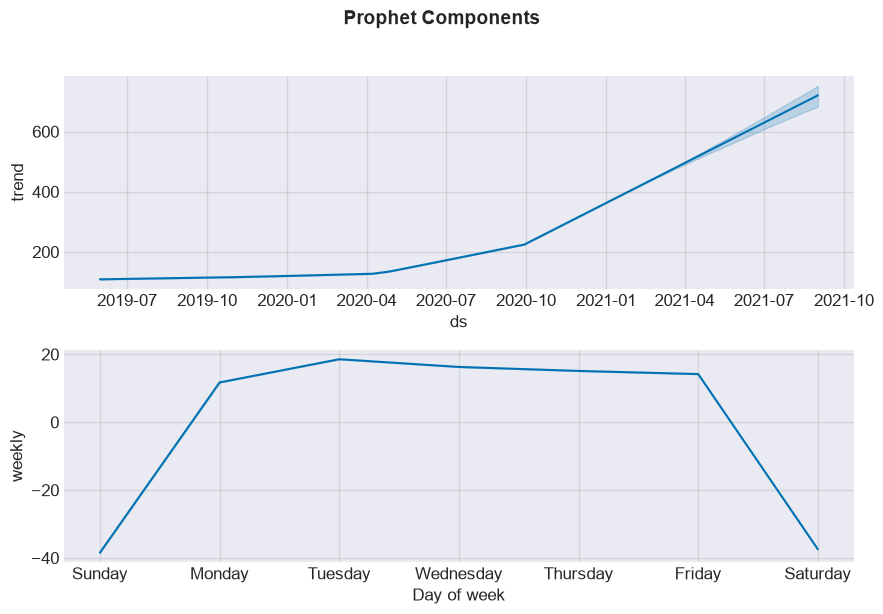

In [19]:
fig = model.plot_components(forecast)
plt.suptitle("Prophet Components", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 12: Walk-Forward Backtesting (Proper Evaluation)

A single 80/20 split can be misleading. Walk-forward backtest:

1. Train on data up to day T
2. Predict next 30 days
3. Slide forward 30 days
4. Repeat N times

Tests the model on **multiple non-overlapping future windows**.

In [20]:
def walk_forward_backtest(df, horizon=30, n_folds=5):
    total = len(df)
    min_train = total - (n_folds * horizon)

    if min_train < 30:
        n_folds = max(1, (total - 30) // horizon)
        min_train = total - (n_folds * horizon)

    fold_results = []
    all_preds = []
    all_actuals = []
    all_dates = []

    for fold in range(n_folds):
        train_end = min_train + (fold * horizon)
        test_end = min(train_end + horizon, total)

        fold_train = df.iloc[:train_end].copy()
        fold_test = df.iloc[train_end:test_end].copy()

        if len(fold_test) == 0:
            continue

        m = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False,
            changepoint_prior_scale=0.1,
        )
        m.fit(fold_train)

        future = m.make_future_dataframe(periods=len(fold_test), freq="B")
        fc = m.predict(future)

        p = fc.tail(len(fold_test))["yhat"].values
        a = fold_test["y"].values
        min_l = min(len(p), len(a))
        p, a = p[:min_l], a[:min_l]

        fold_mae = float(np.mean(np.abs(a - p)))
        fold_mape = float(np.mean(np.abs((a - p) / a)) * 100)
        naive_p = fold_train["y"].iloc[-1]
        fold_naive_mae = float(np.mean(np.abs(a - naive_p)))

        fold_results.append({
            "fold": fold + 1,
            "train_end": str(fold_train["ds"].iloc[-1].date()),
            "test_start": str(fold_test["ds"].iloc[0].date()),
            "test_end": str(fold_test["ds"].iloc[-1].date()),
            "mae": round(fold_mae, 2),
            "mape": round(fold_mape, 2),
            "naive_mae": round(fold_naive_mae, 2),
            "mase": round(fold_mae / fold_naive_mae, 4) if fold_naive_mae > 0 else None,
        })

        all_preds.extend(p)
        all_actuals.extend(a)
        all_dates.extend(fold_test["ds"].values[:min_l])

    all_preds = np.array(all_preds)
    all_actuals = np.array(all_actuals)

    overall_mae = float(np.mean(np.abs(all_actuals - all_preds)))
    overall_mape = float(np.mean(np.abs((all_actuals - all_preds) / all_actuals)) * 100)
    avg_naive = float(np.mean([f["naive_mae"] for f in fold_results]))
    overall_mase = overall_mae / avg_naive if avg_naive > 0 else None

    return {
        "overall": {
            "mae": round(overall_mae, 2),
            "mape": round(overall_mape, 2),
            "mase": round(overall_mase, 4) if overall_mase else None,
            "n_folds": len(fold_results),
        },
        "folds": fold_results,
        "predictions": all_preds,
        "actuals": all_actuals,
        "dates": all_dates,
    }

print("Walk-forward backtest function defined!")

Walk-forward backtest function defined!


In [21]:
# run backtest with 5 folds
print("Running walk-forward backtest (5 folds x 30 days)...")
print("Training 5 separate Prophet models, please wait...\n")

bt = walk_forward_backtest(prophet_df, horizon=30, n_folds=5)

11:48:57 - cmdstanpy - INFO - Chain [1] start processing
11:48:57 - cmdstanpy - INFO - Chain [1] done processing
11:48:57 - cmdstanpy - INFO - Chain [1] start processing


Running walk-forward backtest (5 folds x 30 days)...
Training 5 separate Prophet models, please wait...



11:48:58 - cmdstanpy - INFO - Chain [1] done processing
11:48:58 - cmdstanpy - INFO - Chain [1] start processing
11:48:58 - cmdstanpy - INFO - Chain [1] done processing
11:48:58 - cmdstanpy - INFO - Chain [1] start processing
11:48:58 - cmdstanpy - INFO - Chain [1] done processing
11:48:58 - cmdstanpy - INFO - Chain [1] start processing
11:48:58 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
# per-fold results
print("Per-Fold Results:")
print("=" * 90)
print(f"{'Fold':>5} | {'Train End':>12} | {'Test Range':>27} | {'MAE':>8} | {'MAPE':>8} | {'MASE':>8}")
print("-" * 90)

for row in bt["folds"]:
    mase_str = f"{row['mase']:.4f}" if row["mase"] else "N/A"
    marker = " <-GOOD" if row["mase"] and row["mase"] < 1 else ""
    print(f"{row['fold']:>5} | {row['train_end']:>12} | {row['test_start']} to {row['test_end']} | {row['mae']:>8.2f} | {row['mape']:>7.2f}% | {mase_str:>8}{marker}")

print("=" * 90)
o = bt["overall"]
print(f"\nOverall: MAE={o['mae']}, MAPE={o['mape']}%, MASE={o['mase']}")
if o["mase"] and o["mase"] < 1:
    print("\nModel BEATS naive baseline!")
else:
    print("\nComparable to naive (normal for financial data)")

Per-Fold Results:
 Fold |    Train End |                  Test Range |      MAE |     MAPE |     MASE
------------------------------------------------------------------------------------------
    1 |   2021-02-01 | 2021-02-02 to 2021-03-03 |    61.16 |   13.10% |   1.0411
    2 |   2021-03-03 | 2021-03-04 to 2021-04-02 |   145.90 |   34.54% |   1.5013
    3 |   2021-04-02 | 2021-04-03 to 2021-05-02 |   125.70 |   26.90% |   0.6376 <-GOOD
    4 |   2021-05-02 | 2021-05-03 to 2021-06-01 |   158.30 |   39.12% |   0.6687 <-GOOD
    5 |   2021-06-01 | 2021-06-02 to 2021-07-01 |   137.85 |   39.34% |   5.3983

Overall: MAE=125.78, MAPE=30.6%, MASE=1.0221

Comparable to naive (normal for financial data)


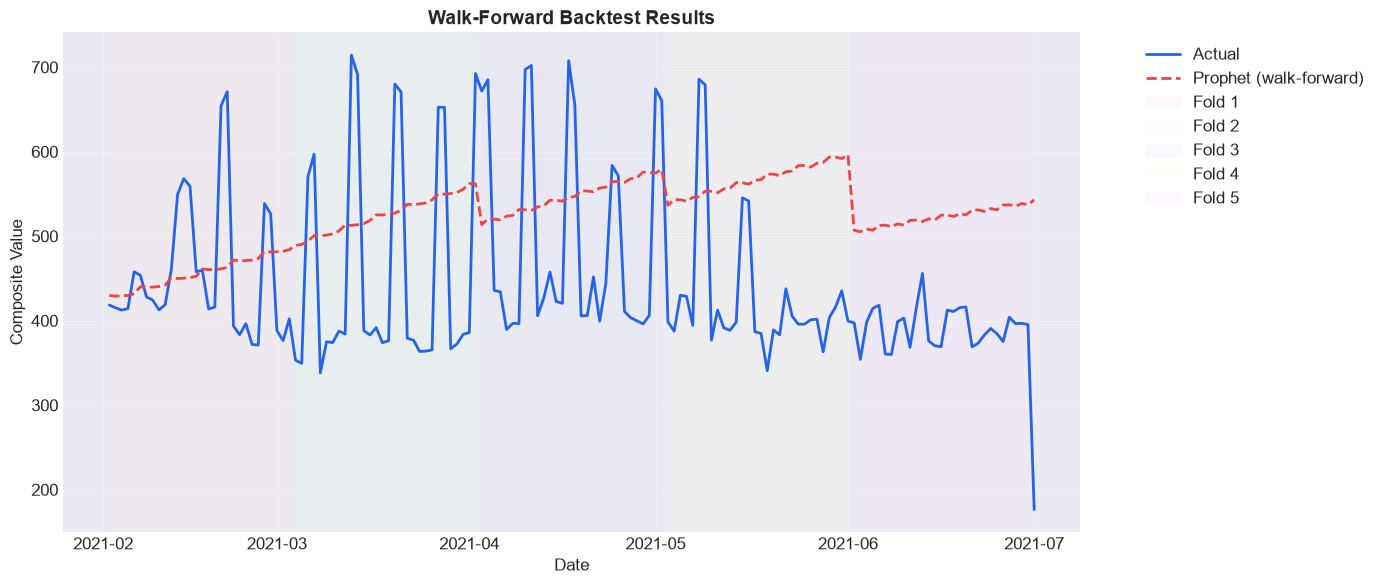

In [23]:
# plot backtest predictions vs actuals
plt.figure(figsize=(14, 6))

bt_dates = pd.to_datetime(bt["dates"])

plt.plot(bt_dates, bt["actuals"], label="Actual", color="#2563EB", linewidth=2)
plt.plot(bt_dates, bt["predictions"], label="Prophet (walk-forward)", color="#ef4444", linewidth=2, linestyle="--")

# shade each fold
colors = ["#FFE4E1", "#E0FFE0", "#E0E0FF", "#FFFFE0", "#FFE0FF"]
for i, row in enumerate(bt["folds"]):
    plt.axvspan(pd.Timestamp(row["test_start"]), pd.Timestamp(row["test_end"]),
                alpha=0.15, color=colors[i % len(colors)], label=f"Fold {row['fold']}")

plt.title("Walk-Forward Backtest Results", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Composite Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

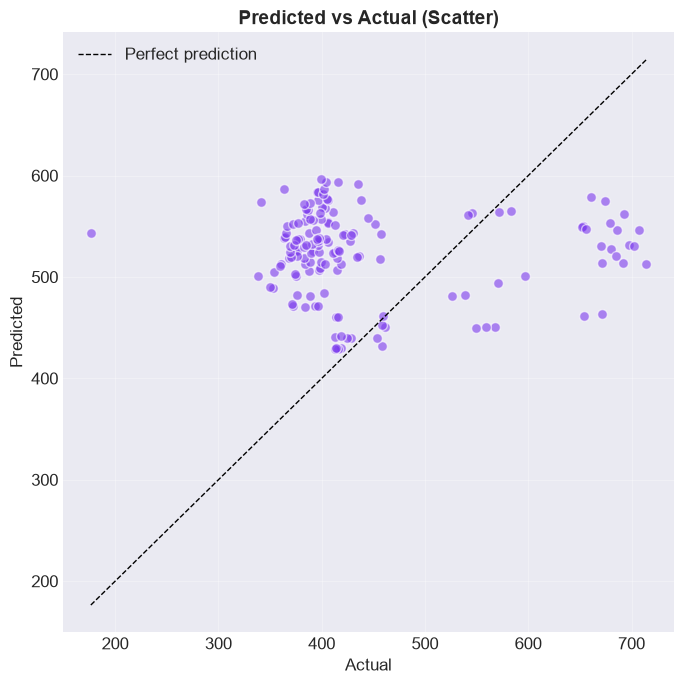

In [24]:
# scatter: predicted vs actual
plt.figure(figsize=(7, 7))

plt.scatter(bt["actuals"], bt["predictions"], alpha=0.6, color="#7C3AED", edgecolors="white", s=50)

lo = min(bt["actuals"].min(), bt["predictions"].min())
hi = max(bt["actuals"].max(), bt["predictions"].max())
plt.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="Perfect prediction")

plt.title("Predicted vs Actual (Scatter)", fontsize=14, fontweight="bold")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13: Error Distribution

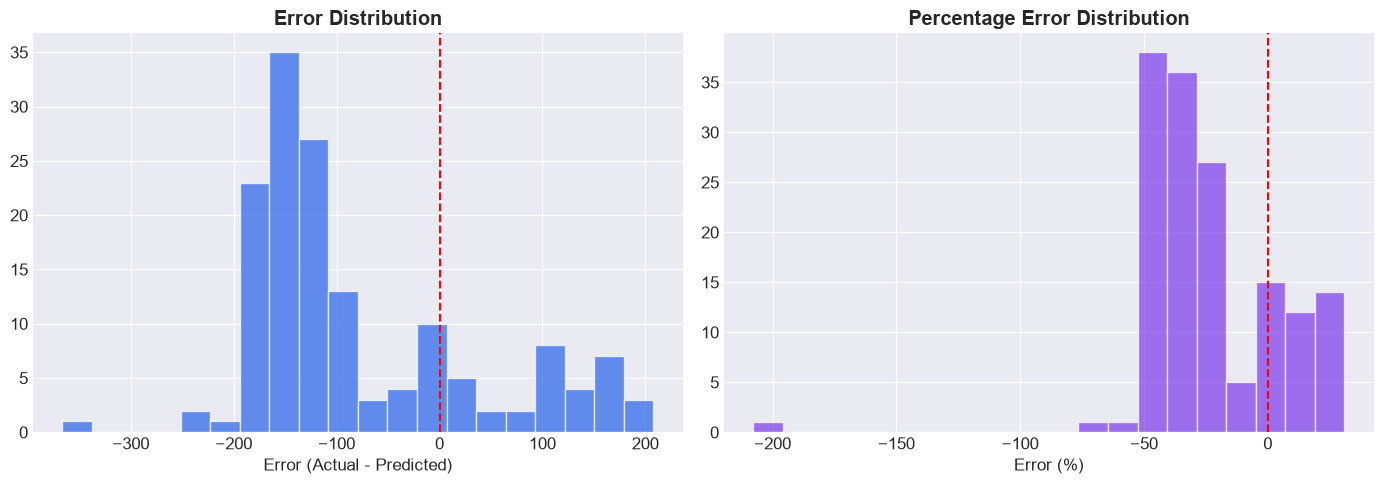

Mean Error:    -79.55 (bias)
Std of Errors: 112.42
Mean % Error:  -23.50%


In [25]:
errors = bt["actuals"] - bt["predictions"]
pct_errors = (errors / bt["actuals"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=20, color="#2563EB", alpha=0.7, edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_title("Error Distribution", fontweight="bold")
axes[0].set_xlabel("Error (Actual - Predicted)")

axes[1].hist(pct_errors, bins=20, color="#7C3AED", alpha=0.7, edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_title("Percentage Error Distribution", fontweight="bold")
axes[1].set_xlabel("Error (%)")

plt.tight_layout()
plt.show()

print(f"Mean Error:    {np.mean(errors):.2f} (bias)")
print(f"Std of Errors: {np.std(errors):.2f}")
print(f"Mean % Error:  {np.mean(pct_errors):.2f}%")

## Step 14: Train Final Model on ALL Data

Now that backtesting is done, train the production model on
the complete dataset for the best possible forecast.

In [26]:
# train on everything
final_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.1,
)

final_model.fit(prophet_df)

print("Final model trained on ALL data!")
print(f"  Rows: {len(prophet_df)}")
print(f"  Range: {prophet_df['ds'].iloc[0].date()} to {prophet_df['ds'].iloc[-1].date()}")
print(f"  Changepoints: {len(final_model.changepoints)}")

11:48:59 - cmdstanpy - INFO - Chain [1] start processing
11:48:59 - cmdstanpy - INFO - Chain [1] done processing


Final model trained on ALL data!
  Rows: 763
  Range: 2019-05-31 to 2021-07-01
  Changepoints: 25


## Step 15: Generate 30-Day Future Forecast

In [27]:
# forecast 30 business days ahead
future_df = final_model.make_future_dataframe(periods=30, freq="B")
final_forecast = final_model.predict(future_df)

future_preds = final_forecast.tail(30)[["ds", "yhat", "yhat_lower", "yhat_upper"]]

print("30-Day Forecast:\n")
print(future_preds.to_string(index=False))

30-Day Forecast:

        ds       yhat  yhat_lower  yhat_upper
2021-07-02 437.519420  368.563997  511.351935
2021-07-05 433.399014  366.603861  509.569243
2021-07-06 438.037122  362.211100  513.027905
2021-07-07 436.957500  363.871683  502.700166
2021-07-08 432.631373  365.281165  505.367743
2021-07-09 437.355718  367.641898  514.036280
2021-07-12 433.235313  363.329152  515.110775
2021-07-13 437.873421  367.471939  511.148230
2021-07-14 436.793798  360.029079  514.572905
2021-07-15 432.467671  364.668911  501.389068
2021-07-16 437.192017  365.458756  506.531342
2021-07-19 433.071611  359.392820  505.732124
2021-07-20 437.709719  366.644441  503.597169
2021-07-21 436.630097  366.723251  511.389172
2021-07-22 432.303970  361.295523  502.027606
2021-07-23 437.028315  367.446997  512.252743
2021-07-26 432.907910  357.284972  509.632477
2021-07-27 437.546018  362.284346  511.356483
2021-07-28 436.466395  365.778173  508.926489
2021-07-29 432.140268  356.650313  508.204401
2021-07-30 436.8

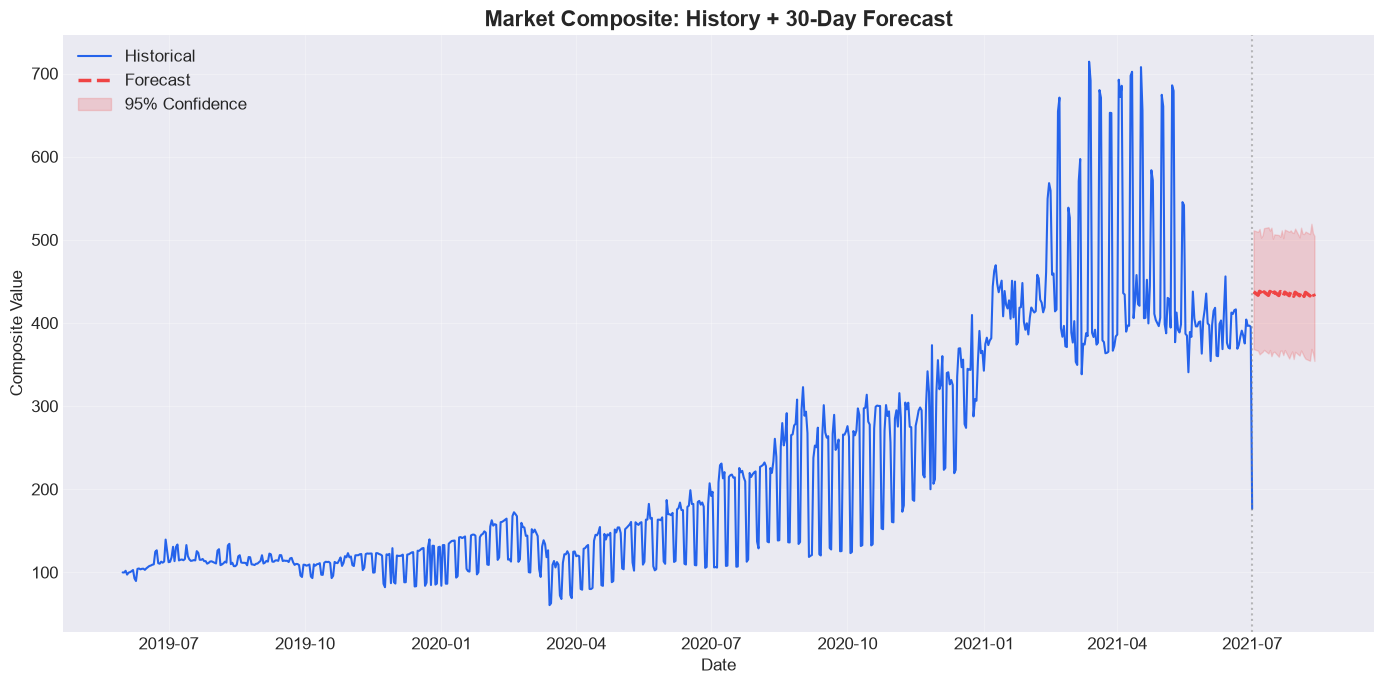

In [28]:
# plot history + forecast
plt.figure(figsize=(14, 7))

plt.plot(prophet_df["ds"], prophet_df["y"], label="Historical", color="#2563EB", linewidth=1.5)
plt.plot(future_preds["ds"], future_preds["yhat"], label="Forecast", color="#ef4444", linewidth=2.5, linestyle="--")
plt.fill_between(future_preds["ds"], future_preds["yhat_lower"], future_preds["yhat_upper"],
                 alpha=0.2, color="#ef4444", label="95% Confidence")
plt.axvline(x=prophet_df["ds"].iloc[-1], color="gray", linestyle=":", alpha=0.5)

plt.title("Market Composite: History + 30-Day Forecast", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Composite Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 16: Final Model Components

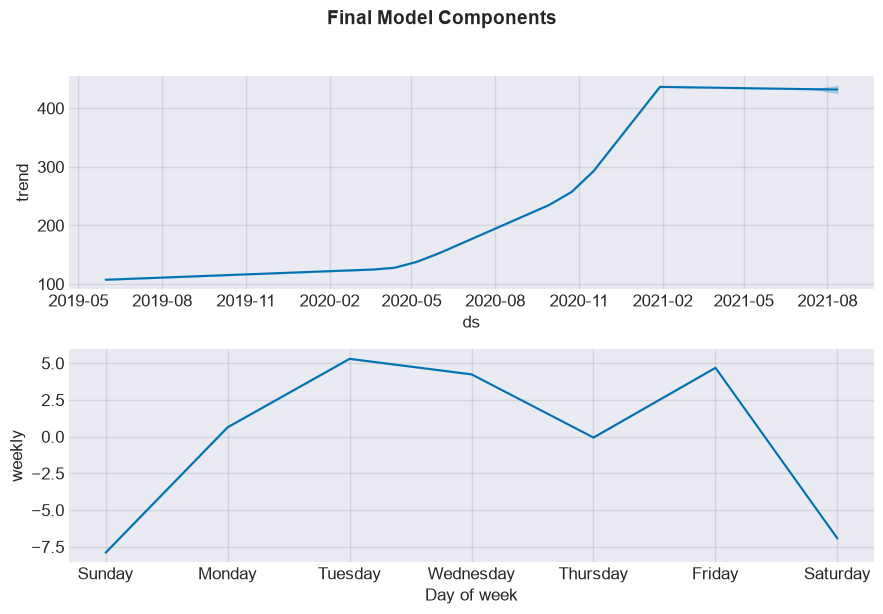

In [29]:
fig = final_model.plot_components(final_forecast)
plt.suptitle("Final Model Components", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 17: Save the Trained Model

In [30]:
# save with joblib
model_path = "../backend/trained_models/prophet_forecast_model.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.1f} KB")

Model saved to: ../backend/trained_models/prophet_forecast_model.pkl
File size: 74.3 KB


## Step 18: Final Summary

In [31]:
print("=" * 60)
print("   FINSIGHT AI - FORECASTING TRAINING SUMMARY")
print("=" * 60)
print()
print(f"Data:")
print(f"  Stocks combined:    {len(stock_data)}")
print(f"  Total data points:  {len(prophet_df)}")
print(f"  Date range:         {prophet_df['ds'].iloc[0].date()} to {prophet_df['ds'].iloc[-1].date()}")
print()
print(f"Model: Prophet")
print(f"  weekly_seasonality: True")
print(f"  yearly_seasonality: False")
print(f"  changepoint_prior:  0.1")
print(f"  forecast freq:      B (business days)")
print()
o = bt["overall"]
print(f"Backtest ({o['n_folds']} folds, 30-day horizon):")
print(f"  MAE:  {o['mae']}")
print(f"  MAPE: {o['mape']}%")
print(f"  MASE: {o['mase']}")
if o["mase"] and o["mase"] < 1:
    print(f"  Model beats naive baseline!")
print()
print(f"Saved: {model_path}")
print()
print("=" * 60)
print("   TRAINING COMPLETE")
print("=" * 60)

   FINSIGHT AI - FORECASTING TRAINING SUMMARY

Data:
  Stocks combined:    11
  Total data points:  763
  Date range:         2019-05-31 to 2021-07-01

Model: Prophet
  weekly_seasonality: True
  yearly_seasonality: False
  changepoint_prior:  0.1
  forecast freq:      B (business days)

Backtest (5 folds, 30-day horizon):
  MAE:  125.78
  MAPE: 30.6%
  MASE: 1.0221

Saved: ../backend/trained_models/prophet_forecast_model.pkl

   TRAINING COMPLETE
